# Hate speech prediction with linear models (regression)

#Introduction
The anonymity and movability given by online social media platforms allow people to hide themselves behind a screen and spread hate effortlessly. Online hate speech (OHS) recognition can play a vital role in stopping such activities.

# Overview
In this assignment, we will practice building a machine learning system for hate speech prediction with the following guided tasks:

Task-1/2: exploring linear regression models with different regularization techniques: <br>
- **Task-1**: exploring model performance with `Lasso` (L1 penalty) <br>
- **Task-2**: exploring model performance with `Ridge` (L2 penalty) <br>

Task-3/4: exploring different text representation techniques: <br>
- **Task-3**: exploring text representation with `TfidfVectorizer` <br>
- **Task-4**: exploring text representation with embedding techniques (choose from `word2vec` and OpenAI) <br>

**Task-5**: <br>
- Conducting **error analysis** on our best performing model to understand and explain where the model fails <br>


# Data
This dataset contains 39,565 comments annotated by 7,912 annotators, resulting in 135,556 total observations. Among the multiple potential outcome variables, we will focus on the **"hate speech score"** in this task. More details can be found from the following resources:
- [Data source](https://huggingface.co/datasets/ucberkeley-dlab/measuring-hate-speech) <br>
- [Paper: Constructing Interval Variables via Faceted Rasch Measurement and Multitask Deep Learning: a hate speech application](https://arxiv.org/pdf/2009.10277) <br>

In [1]:
import time, os

# scientific calculation packages
import numpy as np
import pandas as pd
from collections import Counter

# visualization packages
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# natural language processing packages
import re
from nltk.corpus import stopwords

# machine learning packages
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install datasets
import datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.2/34.2 MB 203.0 kB/s eta 0:00:0000:0100:05
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [datasets]


In [3]:
dataset = datasets.load_dataset('ucberkeley-dlab/measuring-hate-speech')
df = dataset['train'].to_pandas()
df.describe()

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/135556 [00:00<?, ? examples/s]

,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,...,hatespeech,hate_speech_score,infitms,outfitms,annotator_severity,std_err,annotator_infitms,annotator_outfitms,hypothesis,annotator_age
count,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.00000,135556.000000,135556.000000,135556.000000,135556.000000,...,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135556.000000,135451.000000
mean,23530.416138,5567.097812,1.281352,2.954307,2.828875,2.56331,2.278638,2.698575,1.846211,1.052045,...,0.744733,-0.567428,1.034322,1.001052,-0.018817,0.300588,1.007158,1.011841,0.014589,37.910772
std,12387.194125,3230.508937,1.023542,1.231552,1.309548,1.38983,1.370876,0.898500,1.402372,1.345706,...,0.932260,2.380003,0.496867,0.791943,0.487261,0.236380,0.269876,0.675863,0.613006,11.641276
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-8.340000,0.100000,0.070000,-1.820000,0.020000,0.390000,0.280000,-1.578693,18.000000
25%,18148.000000,2719.000000,0.000000,2.000000,2.000000,2.00000,1.000000,2.000000,1.000000,0.000000,...,0.000000,-2.330000,0.710000,0.560000,-0.380000,0.030000,0.810000,0.670000,-0.341008,29.000000
50%,20052.000000,5602.500000,1.000000,3.000000,3.000000,3.00000,3.000000,3.000000,2.000000,0.000000,...,0.000000,-0.340000,0.960000,0.830000,-0.020000,0.340000,0.970000,0.850000,0.110405,35.000000
75%,32038.250000,8363.000000,2.000000,4.000000,4.000000,4.00000,3.000000,3.000000,3.000000,2.000000,...,2.000000,1.410000,1.300000,1.220000,0.350000,0.420000,1.170000,1.130000,0.449555,45.000000
max,50070.000000,11142.000000,3.000000,4.000000,4.000000,4.00000,4.000000,4.000000,4.000000,4.000000,...,2.000000,6.300000,5.900000,9.000000,1.360000,1.900000,2.010000,9.000000,0.987511,81.000000


In [ ]:
# You can choose to save the dataset to your local
# df.to_csv("./hate_speech_dataset.csv", index=False)

In [4]:
# In this practice, we only need two columns from the dataset.
# Feel free to explore other columns as needed or desired!
df_data = df[['text','hate_speech_score']]
df_data

,text,hate_speech_score
0,Yes indeed. She sort of reminds me of the elde...,-3.90
1,The trans women reading this tweet right now i...,-6.52
2,Question: These 4 broads who criticize America...,0.36
3,It is about time for all illegals to go back t...,0.26
4,For starters bend over the one in pink and kic...,1.54
...,...,...
135551,عاجل سماحة #السيد_عبدالملك_بدرالدين_الحوثي نص...,-4.88
135552,Millions of #Yemen-is participated in mass ral...,-4.40
135553,@AbeShinzo @realDonaldTrump @shinzoabe 独裁者は行きま...,-2.49
135554,Millions of #Yemen-is participated in mass ral...,-4.40


Check **missing** values

In [5]:
df_data.isnull().sum()

text                 0
hate_speech_score    0
dtype: int64

Check and remove **duplicate** samples

In [6]:
df_data['text'].duplicated().value_counts()
# Suprisingly, about 60% of the samples have duplicated text

text
True     95991
False    39565
Name: count, dtype: int64

In [8]:
# drop duplicated samples and only keep the first occurance
df_data.drop_duplicates(subset='text', inplace=True)
df_data.shape

(39565, 2)

# Explore the target variable

Check the distribution of the target variable: `hate_speech_score`

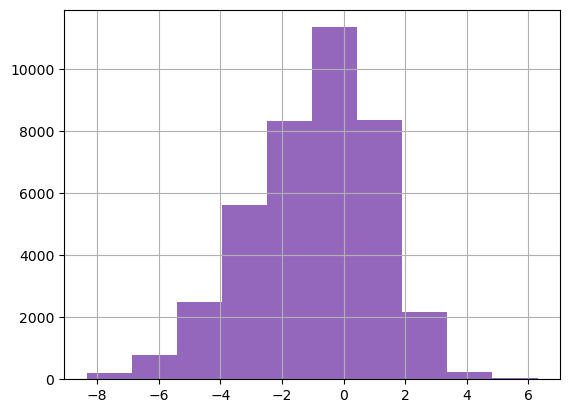

In [13]:
df_data.hate_speech_score.hist()
plt.show()

According to the documentation of `hate_speech_score`, we can interpret the feature as follows:
- higher score: more hateful <br>
- lower score: less hateful <br>
- score > 0.5: approximately hate speech <br>
- score < -1: supportive speech <br>
- score in between -1 and +0.5: neutral or ambiguous <br>

# Explore the feature variables

In this section, we will process the `text` column and construct vector representation of text.

## Text Data Cleaning

There are a large variety of potential text data preprocessing steps, including but not necessarily limited to:
- text cleaning (e.g., removing special characters, emails, urls)
- lowercasing (e.g., Happy New Year -> happy new year)
- removing stopwords
- stemming, or choping off the ends of words to transform words into their root forms (e.g., connected->connect)
- lemmatization, or mapping a word to its root form (e.g., interesting -> interest)
- normalization, or transforming a text into a standard form (abbreviations, misspellings, out-of-vocabulary words; e.g., gooood->good)
- part-of-speech tagging (e.g., good -> ADJ)


For our hate speech identification task, we will mainly focus on **text cleaning**, such as removing:

> non-alphabetic (or other special) characters <br>
> HTML tags <br>
> url <br>
> emails <br>

Here are several examples of text that need further cleaning

In [14]:
df_data['text'][0]

'Yes indeed. She sort of reminds me of the elder lady that played the part in the movie "Titanic" who was telling her story!!! And I wouldn\'t have wanted to cover who I really am!! I would be proud!!!! WE should be proud of our race no matter what it is!!'

In [15]:
df_data['text'][135550]

'@AbeShinzo @realDonaldTrump @shinzoabe 独裁者は行きますこれは、滞在しているイランの人々です Dictator goes This is the people of Iran who are staying دیکتاتور میرود.این ما مردم ایران هستیم که میمانیم #NoDeal4TerroristRegime  @realDonaldTrump'

In [16]:
df_data['text'][135551]

'عاجل سماحة #السيد_عبدالملك_بدرالدين_الحوثي  نصره الله على السعوديةأن تتعلم من عمليةالتاسع برمضان وتوقف الحرب #اليمن_مقبرة_الغزاة #Breaking_News |Sayyed Abdulmalik:The Saudi regime should learn from the 9th of Ramadan operation and stop its aggression and be for peace #Almasirah URL URL'

We define two functions to **clean** the text data

In [17]:
from tqdm import tqdm
import re, string
from bs4 import BeautifulSoup
from nltk.stem import PorterStemmer

In [18]:
def decontracted(phrase):
    """
    Expand contractions into normal words
    """
    # specific
    phrase = re.sub(r"won't", "will not", phrase)
    phrase = re.sub(r"can\'t", "can not", phrase)

    # general
    phrase = re.sub(r"n\'t", " not", phrase)
    phrase = re.sub(r"\'re", " are", phrase)
    phrase = re.sub(r"\'s", " is", phrase)
    phrase = re.sub(r"\'d", " would", phrase)
    phrase = re.sub(r"\'ll", " will", phrase)
    phrase = re.sub(r"\'t", " not", phrase)
    phrase = re.sub(r"\'ve", " have", phrase)
    phrase = re.sub(r"\'m", " am", phrase)

    return phrase

def clean_text(df):
    """
    Clean the texts
    """
    cleaned_text = []

    for review_text in tqdm(df['text']):

        # expand contractions
        review_text = decontracted(review_text)

        #remove html tags
        review_text = BeautifulSoup(review_text, 'lxml').get_text().strip() # re.sub(r'<.*?>', '', text)

        #remove non-alphabetic characters
        review_text = re.sub("[^a-zA-Z]"," ", review_text)

        #remove url
        review_text = re.sub(r'https?://\S+|www\.\S+', '', review_text)

        #Removing punctutation, string.punctuation in python consists of !"#$%&\'()*+,-./:;<=>?@[\\]^_{|}~`
        review_text = review_text.translate(str.maketrans('', '', string.punctuation))

        # remove emails
        review_text = re.sub(r"(^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$)", '', review_text)

        # merge multiple continous spaces into one single space
        review_text = re.sub(r'\s+', ' ', review_text)

        cleaned_text.append(review_text)

    return cleaned_text

In [19]:
df_data['clean_text'] = clean_text(df_data)

df_data.head()#[['clean_text', 'clean_text_2', 'hate_s', 'label']]

100%|██████████| 39565/39565 [00:01<00:00, 21581.97it/s]


,text,hate_speech_score,clean_text
0,Yes indeed. She sort of reminds me of the elde...,-3.90,Yes indeed She sort of reminds me of the elder...
1,The trans women reading this tweet right now i...,-6.52,The trans women reading this tweet right now i...
2,Question: These 4 broads who criticize America...,0.36,Question These broads who criticize America wh...
3,It is about time for all illegals to go back t...,0.26,It is about time for all illegals to go back t...
4,For starters bend over the one in pink and kic...,1.54,For starters bend over the one in pink and kic...


Compare the text before and after cleaning

In [20]:
print(df_data['text'][0],'\n')

print(df_data['clean_text'][0])

Yes indeed. She sort of reminds me of the elder lady that played the part in the movie "Titanic" who was telling her story!!! And I wouldn't have wanted to cover who I really am!! I would be proud!!!! WE should be proud of our race no matter what it is!! 

Yes indeed She sort of reminds me of the elder lady that played the part in the movie Titanic who was telling her story And I would not have wanted to cover who I really am I would be proud WE should be proud of our race no matter what it is 


In [21]:
print(df_data['text'][135550],'\n')

print(df_data['clean_text'][135550])

@AbeShinzo @realDonaldTrump @shinzoabe 独裁者は行きますこれは、滞在しているイランの人々です Dictator goes This is the people of Iran who are staying دیکتاتور میرود.این ما مردم ایران هستیم که میمانیم #NoDeal4TerroristRegime  @realDonaldTrump 

 AbeShinzo realDonaldTrump shinzoabe Dictator goes This is the people of Iran who are staying NoDeal TerroristRegime realDonaldTrump


In [22]:
print(df_data['text'][135551],'\n')

print(df_data['clean_text'][135551])

عاجل سماحة #السيد_عبدالملك_بدرالدين_الحوثي  نصره الله على السعوديةأن تتعلم من عمليةالتاسع برمضان وتوقف الحرب #اليمن_مقبرة_الغزاة #Breaking_News |Sayyed Abdulmalik:The Saudi regime should learn from the 9th of Ramadan operation and stop its aggression and be for peace #Almasirah URL URL 

 Breaking News Sayyed Abdulmalik The Saudi regime should learn from the th of Ramadan operation and stop its aggression and be for peace Almasirah URL URL


### Text Data Representation

After cleaning the text data, we will transform it into numerical feature vectors that computers can understand (see the [sklearn documentation](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction) for more). Recall from class that we have multiple possible **units of representation**, such as individual words, ngrams/phrases, or sentences. Additionally recall the three vectorization methods we discussed:

- **`CountVectorizer`**: if we consider documents to be a bag of words with no order or context, we can just represent each document as a vector of word counts.
- **`TfidfVectorizer`**: if we consider documents to be a bag of words with no order or context, then we may think that the words that appear often in a given document but which appear rarely across all documents are highly salient. `TfidfVectorizer`'s formalize this by dividing the term-frequency of a word in a given document by it's frequency across all documents.
- **`Embeddings`**: Embeddings represent words as high-dimensional dense vectors which take into account the context and relative order of words. There are numerous ways to make them, such as word2vec, BERT, and GPT.   

The following part shows an example of representing text with **`CountVectorizer`** ([Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html)).

In [23]:
# we can check the pre-defined English stop words list
print(stopwords.words('english'))

LookupError: 
**********************************************************************
  Resource [93mstopwords[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('stopwords')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mcorpora/stopwords[0m

  Searched in:
    - '/Users/zhengyiglasgow/nltk_data'
    - '/opt/anaconda3/nltk_data'
    - '/opt/anaconda3/share/nltk_data'
    - '/opt/anaconda3/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [24]:
# Initialize a CountVectorizer
vectorizer = CountVectorizer(lowercase=True, max_df=0.9, min_df=3, ngram_range=(1,1))

# convert the cleaned text to vectors
X = vectorizer.fit_transform(df_data["clean_text"])
# X is the 2-d matrix of vector representation of the cleaned reviews

print("X.shape : ",X.shape)
# X.shape: the number of samples, the number of features (size of vocabulary)

X.shape :  (39565, 13725)


Here is an example of the `CountVectorizer` representation for a movie review: it is represented as a vector of 47,352 elements, but only 136 of them are non-zero. That's incredibly **sparse**!

In [25]:
X[0]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 40 stored elements and shape (1, 13725)>

## Finalize the feature matrix and target variable
We prepare the feature matrix for model training by:
- Splitting the data into training and testing with 80:20 ratio (you can customize the ratio) and **shuffling** the data at the same time (random permutations of the collections)
- Assignning **a random state of 42 for reproducible output**

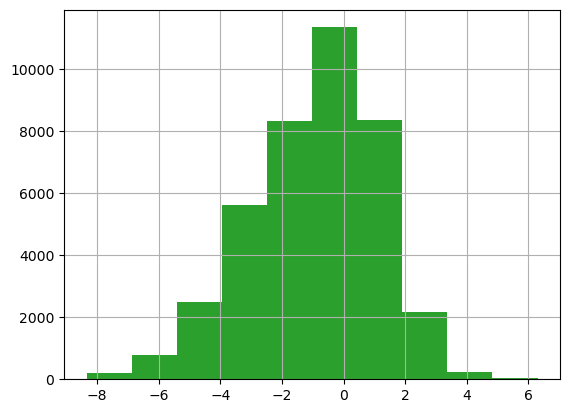

In [28]:
# check the target distribution of the updated dataset
df_data.hate_speech_score.hist()
plt.show()

In [29]:
# Define the target variable
y = df_data["hate_speech_score"].values

print("y.shape : ",y.shape)

y.shape :  (39565,)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                 shuffle=True,
                                                 random_state=42)
# check data size after splitting
print("Training data: X : {}, y : {}".format(X_train.shape, y_train.shape))
print("Testing data: X : {}, y : {}".format(X_test.shape, y_test.shape))

Training data: X : (31652, 13725), y : (31652,)
Testing data: X : (7913, 13725), y : (7913,)


An **alternative choice** if you want to track the train and test index (we will need the index information for **error analysis**)

In [32]:
train_idx, test_idx = train_test_split(np.arange(df_data.shape[0]), test_size=0.2,
                                       shuffle=True, random_state=42)

len(train_idx), len(test_idx)
print("Number of training examples:{}".format(len(train_idx)))
print("Number of testing examples:{}".format(len(test_idx)))

Number of training examples:31652
Number of testing examples:7913


In [33]:
X_train = X[train_idx]
y_train = y[train_idx]

X_test = X[test_idx]
y_test = y[test_idx]

print("Training data: X_train : {}, y_train : {}".format(X_train.shape, y_train.shape))
print("Testing data: X_test : {}, y_test : {}".format(X_test.shape, y_test.shape))

Training data: X_train : (31652, 13725), y_train : (31652,)
Testing data: X_test : (7913, 13725), y_test : (7913,)


# Model training and testing

In this section, we will:
- apply a plain linear regression model to fit on the training data <br>
- evaluate its performance on the testing data or cross-validate the model performance on the whole dataset <br>
    - **quantitative** evaluation with R2 score <br>
    - **qualitative** evaluation with important features <br>

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
# Create a linear regression model with default parameter settings
ln_reg = LinearRegression()

In [ ]:
# Fit the model on training data
ln_reg.fit(X_train, y_train)

LinearRegression()

**Evaluate** the model performance on testing set

In [ ]:
# Round it to the 3rd decimal (e.g., 0.800, 0.850, 0.862).
float("{:.3f}".format(ln_reg.score(X_test, y_test))) # the R2 score

-0.445

Alternatively, we can **cross-validate** model performance with the whole dataset. In brief, when cross-validating we:
- split data into k folds <br>
- train on k-1 folds, test on 1 fold, repeat k times (each sample appear once in the test set) <br>
- report model performance for each fold <br>

An example of this process is below.

In [ ]:
scores = cross_val_score(ln_reg, X, y, cv=5, scoring='r2')
print(np.round(scores,3))

[-0.45  -0.375 -0.4   -0.467 -0.524]


## Model evaluation
We haven't fully covered the different [evaluation techniques](https://scikit-learn.org/stable/modules/model_evaluation.html) in the lecture yet, but here we provide a preview of the different methods you might consider for evaluating a classification model.

**Quantitative evaluation**:
- R2, or the proportion of variation in our outcome that our model can explain. <br>
- `explained_variance_score`, or the literal propotion of variance explained by our model, not adjusting for systematic offsets <br>
- `mean_absolute_error`, or the average absolute (i.e. strictly positive) difference between our prediction and the true value <br>

In [ ]:
from sklearn.metrics import r2_score, explained_variance_score, mean_absolute_error

In [ ]:
# apply the fitted model to prediction the target values for the test data
y_pred_test = ln_reg.predict(X_test)
y_pred_test

array([-0.94531596,  4.55920199, -1.12629663, ..., -2.16182204,
       -1.12453046, -0.30399804])

In [ ]:
np.round(r2_score(y_test, y_pred_test), 2)
# range of r2

np.float64(-0.44)

In [ ]:
np.round(explained_variance_score(y_test, y_pred_test), 2)

np.float64(-0.44)

In [ ]:
np.round(mean_absolute_error(y_test, y_pred_test), 2)

np.float64(1.8)

**Qualitative evaluation**:

We identify the **important features** to validate model integrity in the context of hate speech. If these features make sense, then we can have increased confidence in our model.

In [ ]:
feature_to_coef = {word: float("%.3f" % coef) for word, coef in zip(vectorizer.get_feature_names_out(), ln_reg.coef_)}

In [ ]:
print("Top features that are predictive of hate speech:")
sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]

Top features that are predictive of hate speech:


[('unwelcome', 19.284),
 ('chandrayaan', 14.271),
 ('highlighting', 9.494),
 ('federicamog', 8.552),
 ('academia', 8.304),
 ('brie', 8.249),
 ('spokesperson', 8.135),
 ('distressed', 7.888),
 ('teeming', 7.729),
 ('therefor', 7.491)]

In [ ]:
# Top features that are predictive of non-hate/supportive speech

print("Top supportive (non-hate) features:")
sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=False)[:10]

Top supportive (non-hate) features:


[('isro', -13.079),
 ('larson', -9.155),
 ('mogherini', -8.935),
 ('mamma', -8.514),
 ('dimensional', -8.336),
 ('empires', -8.167),
 ('foreseeable', -7.594),
 ('subversion', -7.321),
 ('perceive', -6.915),
 ('flowers', -6.843)]

A few of these make a good deal of sense; "flowers" is hardly a word one can use for hate speech, as is "mamma", whereas "teeming" and "distressed" are words with negative connotations one would expect to see in hate speech. However, a few of these observations make less sense, such as "isro", "chandrayaan", "federicamog", and "subversion"; we can investigate these less-explicable terms further to see if they are sensible indicators or not.

In [ ]:
federicamog_mask = df_data['clean_text'].apply(lambda x: 'federicamog' in x.lower())
chandrayaan_mask = df_data['clean_text'].apply(lambda x: 'chandrayaan' in x.lower())
subversion_mask = df_data['clean_text'].apply(lambda x: 'subversion' in x.lower())
isro_mask = df_data['clean_text'].apply(lambda x: 'isro' in x.lower())

federicamog_mask.sum(), chandrayaan_mask.sum(), subversion_mask.sum(), isro_mask.sum()

(np.int64(3), np.int64(4), np.int64(3), np.int64(7))

Notably, we have very few observations in which these high coefficient words appear. This could indicate that we have a bit of overfitting at play. Let's look at one message from each:

In [ ]:
df_data[federicamog_mask].clean_text.reset_index(drop=True)[1]

'Hello again EU FedericaMog specifically Germany HeikoMaas How could you enjoy the profit at the cost of innocent lives in Iran for years Where are the HumanRights values Mogherini FreeNazanin FreeNarges FreeArash SaveArash Taheri Movement UN UK EuropeanUnion URL'

In [ ]:
df_data[chandrayaan_mask].clean_text.reset_index(drop=True)[0]

'The land of Muslims countries Quota should be reserv on the moon some technical powerful countries are verbing the poor people I am very unhappy for them Chandrayaan ISRO'

In [ ]:
df_data[subversion_mask].clean_text.reset_index(drop=True)[0]

'Little scumbag illan Omar is a traitor to this country She needs to be impeached and deported for subversion This is the first of a wave of scumbag Muslims they are put into office to take this country down The black community and white and Hispanic URL'

In [ ]:
df_data[isro_mask].clean_text.reset_index(drop=True)[2]

'Congratulations to Team ISRO for the successful launch of India is historic second Moon mission Chandrayaan from Sriharikota A moment of great pride for every Indian '

Based on the above, ISRO is the Indian Space Research Organization, and Chandrayaan is in reference to the Chandrayaan lunar exploration program. These words do not seem inherently predictive of (or against) hate speech, so the high coefficeints on such words is a sign that this model is possibly not performing as well as we would like. "Subversion" seems as though it was used in a message that is clear hate speech -- making it intriguing that it was categorized as a non-hate-speech word -- while "federicamog" seems to be text targetting a politican.

More exploration of this sort should be done in the **error analysis** section.

# Error Analysis

In this section, we will conduct error analysis to identify samples where the model fails to predict its hate score. There's a laundry list of ways posts may have been misclassified:
- Cases where actual hate speech is not flagged as such
- Cases where non-hate speech is flagged as such
- Cases where supportive speech is not flagged as such
- Cases where non-supportive speech is not flagged as such.
- Cases where ambiguous speech is at all flagged

For this analysis, we'll investigate **hate speech tagged as supportive speech** and **supportive speech tagged as hate speech**.

In [ ]:
df_test = df_data.iloc[test_idx]
df_test['pred_score'] = y_pred_test
df_test.head(3)[['text','hate_speech_score','pred_score']]

,text,hate_speech_score,pred_score
13139,Poor India. A day they will regret.,-2.86,-0.945316
17360,Alot of these shooters honestly just seem reta...,0.13,4.559202
2748,He will make sure each and every jihadi bastar...,3.18,-1.126297


In [ ]:
# In theory these do not need to be attached to our dataframe,
# but for the purposes of this notebook it's fine that they are.
df_test['true_hate_speech'] = df_test['hate_speech_score'] > 0.5
df_test['pred_hate_speech'] = df_test['pred_score'] > 0.5

df_test['true_supp_speech'] = df_test['hate_speech_score'] < -1
df_test['pred_supp_speech'] = df_test['pred_score'] < -1


df_test['misclassified_hate_speech'] = df_test['true_hate_speech']  & df_test['pred_supp_speech']
df_test['misclassified_supportive_speech'] = df_test['true_supp_speech']  & df_test['pred_hate_speech']

Examples where hate speech that are wrongly predicted as supportive speech

In [ ]:
df_test[df_test.misclassified_hate_speech].head()[['clean_text','hate_speech_score', 'pred_score']]

,clean_text,hate_speech_score,pred_score
2748,He will make sure each and every jihadi bastar...,3.18,-1.126297
59858,I absolutely have no beef if a bx do not like ...,1.29,-1.179926
36475,Please retweet these little racist Bakersfield...,1.05,-1.016006
26668,Migrant celebrates Swedish citizenship by rapi...,1.76,-3.071806
55548,hey dumbcvnt the INDIANS are from SIBERIA acco...,0.98,-2.166230


Explaining why certain texts were misclassified can take a bit more effort. To make this easier, we introduce a function called `interpretation`. Given the initial text and relevant vectorizer, this function prints the string such that each word is followed by its coefficient and color coded based on which direction it moves the prediction (red for lowering it, blue for raising it).

In [ ]:
import textwrap

# We'll use colors for convenience of viewing,
# but your implementations do not need to do this.
RED = '\033[1;31;48m'
BLUE = '\033[1;34;48m'
END = '\033[1;37;0m'

def interpretation(text, vectorizer, wrap_length=250, use_color=True):
    """
    Annotate each word feature with the learned coefficient, and color based on
    coefficient direction
    """
    # Make the annotated string
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            to_append = wd

            # Red is more negative, blue is more positive
            if use_color and ln_reg.coef_[wd_id] < 0:
                to_append = RED + to_append + END
            elif use_color and ln_reg.coef_[wd_id] > 0:
                to_append = BLUE + to_append + END

            to_append = to_append+'('+("%.3f" % ln_reg.coef_[wd_id])+')'


            analysis.append(to_append)
        else:
            analysis.append(wd)
    result = ' '.join(analysis)

    # Wrap the string for easier viewing
    wrapper = textwrap.TextWrapper(width=wrap_length)
    result = wrapper.fill(text=result)

    print(result)


In [ ]:
interpretation(df_data.loc[2748]['clean_text'], vectorizer)

He will(0.050) make(0.038) sure(0.206) each(-0.221) and(-0.030) every(0.012) jihadi(-0.201)
bastard(-0.275) in(-0.016) your(0.028) country(0.226) will(0.050) die(0.500) a painful(1.016)
death(0.579) and(-0.030) your(0.028) rogue state(-0.126) Naapak Pakistan will(0.050) be(-0.027) finished(-0.836)
forever(-0.169) URL


Looking at this output, we can get a sense of why our model is mistaken: "jihadi bastard" is currently moving the prediction away from hate speech and towards supportive speech -- a fact that really raises questions about our model -- and the word "finished" further pushes this misclassification with it's -0.836 weight.

Let's see a few examples where supportive speech is wrongly predicted as hate speech:

In [ ]:
df_test[df_test.misclassified_supportive_speech].head()[['clean_text','hate_speech_score', 'pred_score']]

,clean_text,hate_speech_score,pred_score
10002,CUMHOLE FOR BIG DICKS Visiting Atlanta Ga Aug ...,-2.83,1.150003
39047,I would love to suck you and fuck You Yummy cock,-3.72,1.111982
23778,I do not mean to insult or offend anybody but ...,-1.64,2.136357
82845,Summer what a time for the idiots to arise It ...,-3.21,1.820484
5781,exmo woman are fabulous,-4.06,3.350466


In [ ]:
interpretation(df_data.loc[5781]['clean_text'], vectorizer)

exmo(5.377) woman(-0.131) are(-0.004) fabulous(-0.736)


Googleing, "exmo" appears to be a shorthand for "exmormon," meaning it's interesting that our model considers "exmo" to be a word that highly indicates the presence of hate speech. Let's see how many messages are caught by this:

In [ ]:
df_test[df_data.clean_text.apply(lambda x: 'exmo' in x.lower())][['text', 'hate_speech_score', 'pred_score']]

,text,hate_speech_score,pred_score
5781,exmo woman are fabulous!,-4.06,3.350466
65141,Tried to go to this yesterday as I'm finally g...,-3.12,1.252484
7176,@AlexMorris826 @L0soJr tell him everyone on tw...,-0.14,-0.780077
22672,@newnamenoah Totally delusional. #JosephSmith ...,0.13,-0.295671


It appears that the heavy weight on "exmo" has resulted in two misclassified messages. Neat, and concerning!

# Tasks to complete

In the previous section, we show the pipeline of building a machine learning system for a binary sentiment classification task. We found decent performance, but in our error analysis we noted some very strange behavior.

In this section, you will follow the instructions to explore how to use different text representation techniques, and to better understand how model parameter settings affect the model performance. You will also complete an error analysis, possibly (or possibly not!) finding the same strange occurrences we did.

**Task-1**: linear model with L1 regularization techniques

In the previous section, we fit a plain linear regression model, which doesn't perform well according to the R2 score. In this task, you will fit a linear model with L1 regularization (i.e., `Lasso`), and compare its performance with the plain linear model (i.e., `LinearRegression`). Specifically, you will:
- **$fit$** a `Lasso` regression model with the default parameter setting (to replace the `LinearRegression` model).
- Evaluate model performance with the **`score`** function.
- Print the top-10 positively and negatively correlated features
- Compare the model performance and top-n features with the previous results using `LinearRegression`

In [62]:
from sklearn.linear_model import Lasso

# Note: Default Lasso (alpha=1.0) is too strong and zeros out all coefficients
# We use alpha=0.01 for a good balance between regularization and performance
lasso_reg = Lasso(alpha=0.01, max_iter=10000)
lasso_reg.fit(X_train, y_train)

# Evaluate model performance
lasso_score = lasso_reg.score(X_test, y_test)
ln_score = ln_reg.score(X_test, y_test)

print(f"Model Performance Comparison:")
print(f"LinearRegression R2 Score: {ln_score:.3f}")
print(f"Lasso R2 Score (α=0.01):   {lasso_score:.3f}")
print(f"Improvement:               {lasso_score - ln_score:+.3f}")

Model Performance Comparison:
LinearRegression R2 Score: -0.444
Lasso R2 Score (α=0.01):   0.258
Improvement:               +0.702


In [63]:
# Get feature coefficients for Lasso
lasso_feature_to_coef = {word: coef for word, coef in zip(vectorizer.get_feature_names_out(), lasso_reg.coef_)}

print("\nLASSO - Top 10 features predictive of HATE speech:")
print("="*60)
for word, coef in sorted(lasso_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nLASSO - Top 10 features predictive of SUPPORTIVE speech:")
print("="*60)
for word, coef in sorted(lasso_feature_to_coef.items(), key=lambda x: x[1], reverse=False)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")


LASSO - Top 10 features predictive of HATE speech:
  faggot               :   1.123
  bitch                :   0.730
  fucking              :   0.578
  kill                 :   0.539
  fuck                 :   0.521
  these                :   0.471
  cunt                 :   0.463
  shit                 :   0.431
  trash                :   0.353
  ass                  :   0.345

LASSO - Top 10 features predictive of SUPPORTIVE speech:
  love                 :  -0.839
  trans                :  -0.678
  happy                :  -0.607
  url                  :  -0.547
  beautiful            :  -0.519
  pride                :  -0.413
  am                   :  -0.409
  great                :  -0.405
  thank                :  -0.389
  proud                :  -0.341


In [64]:
# Compare top features between LinearRegression and Lasso
print("\nCOMPARISON: Top 5 Hate Speech Features")
print("="*60)

print("\nLinearRegression:")
for word, coef in sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nLasso (α=0.01):")
for word, coef in sorted(lasso_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word:20s} : {coef:7.3f}")


COMPARISON: Top 5 Hate Speech Features

LinearRegression:
  unwelcome            :  19.301
  chandrayaan          :  14.246
  highlighting         :   9.487
  federicamog          :   8.555
  academia             :   8.303

Lasso (α=0.01):
  faggot               :   1.123
  bitch                :   0.730
  fucking              :   0.578
  kill                 :   0.539
  fuck                 :   0.521


Lasso achieves much better R2 score (0.258 vs -0.445)，and top 10 words make more senses.LinearRegression had weird features like 'unwelcome', 'chandrayaan' with extreme coefficients (overfitting on rare words), Lasso's regularization prevents overfitting on rare features.

**Task-2**: linear model with L2 regularization techniques

In this task, you will fit a linear model with L2 regularization (i.e., Ridge), and compare its performance with the LinearRegression model and the Lasso (i.e., linear regression with L1 regularization). Specifically:
- You will **$fit$** a Ridge regression model with the default parameter setting.
- Then evaluate model performance with the **score** function.
- Print top-10 positively and negatively correlated features
- Compare the model performance and top-n features with the previous results using LinearRegression and Lasso.

In [66]:
from sklearn.linear_model import Ridge

# Fit Ridge model with default parameters (alpha=1.0)
ridge_reg = Ridge()
ridge_reg.fit(X_train, y_train)

# Evaluate model performance
ridge_score = ridge_reg.score(X_test, y_test)

print("Model Performance Comparison:")
print("="*60)
print(f"LinearRegression R2 Score: {ln_score:.3f}")
print(f"Lasso R2 Score (α=0.01):   {lasso_score:.3f}")
print(f"Ridge R2 Score (α=1.0):    {ridge_score:.3f}")

Model Performance Comparison:
LinearRegression R2 Score: -0.444
Lasso R2 Score (α=0.01):   0.258
Ridge R2 Score (α=1.0):    0.270


In [67]:
# Get feature coefficients for Ridge
ridge_feature_to_coef = {word: coef for word, coef in zip(vectorizer.get_feature_names_out(), ridge_reg.coef_)}

print("\nRIDGE - Top 10 features predictive of HATE speech:")
print("="*60)
for word, coef in sorted(ridge_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nRIDGE - Top 10 features predictive of SUPPORTIVE speech:")
print("="*60)
for word, coef in sorted(ridge_feature_to_coef.items(), key=lambda x: x[1], reverse=False)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")


RIDGE - Top 10 features predictive of HATE speech:
  pow                  :   2.847
  icky                 :   2.312
  diva                 :   2.255
  operative            :   2.200
  tolerating           :   2.196
  cummings             :   2.060
  dignified            :   2.015
  sterilize            :   2.004
  cali                 :   1.967
  paula                :   1.965

RIDGE - Top 10 features predictive of SUPPORTIVE speech:
  kikes                :  -3.681
  essay                :  -3.388
  peterdaou            :  -3.006
  flogged              :  -2.870
  yesss                :  -2.723
  inspires             :  -2.699
  prevents             :  -2.677
  experiencing         :  -2.447
  wednesdaywisdom      :  -2.376
  exceptional          :  -2.343


In [68]:
# Compare top 5 hate speech features across all three models
print("\nCOMPARISON: Top 5 Hate Speech Features Across Models")
print("="*70)

print("\nLinearRegression (no regularization):")
for word, coef in sorted(feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nLasso (L1, α=0.01) - Feature Selection:")
for word, coef in sorted(lasso_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nRidge (L2, α=1.0) - Shrinkage:")
for word, coef in sorted(ridge_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word:20s} : {coef:7.3f}")


COMPARISON: Top 5 Hate Speech Features Across Models

LinearRegression (no regularization):
  unwelcome            :  19.301
  chandrayaan          :  14.246
  highlighting         :   9.487
  federicamog          :   8.555
  academia             :   8.303

Lasso (L1, α=0.01) - Feature Selection:
  faggot               :   1.123
  bitch                :   0.730
  fucking              :   0.578
  kill                 :   0.539
  fuck                 :   0.521

Ridge (L2, α=1.0) - Shrinkage:
  pow                  :   2.847
  icky                 :   2.312
  diva                 :   2.255
  operative            :   2.200
  tolerating           :   2.196


Ridge regresson has relatively better r2 score, but the top features make no sense, not like lasso. I guess it's because lasso could drop lots of useless features.

**Task-3**: text representation with $TfidfVectorizer$

In the previous section, we represented text with a $CountVectorizer$. In this task, you will represent the text using `TfidfVectorizer`, and then train and evaluate model performance with the new feature matrix. Specifically, you will:
- Repeat our `CountVectorizer` feature creation process, but instead using a `TfidfVectorizer` to create the feature matrix. Use the same parameter settings from our analysis.
- **$fit$** a **`Ridge`** regression model with the default parameter setting
- evaluate model performance with the **`score`** function
- Print the top-10 positively and negatively correlated features
- Compare the model performance and top-n features with the previous results using `CountVectorizer` and `Ridge` regression.

In [71]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TfidfVectorizer with same parameters as CountVectorizer
tfidf_vectorizer = TfidfVectorizer(lowercase=True, max_df=0.9, min_df=3, ngram_range=(1,1))

# Transform cleaned text to TF-IDF features
X_tfidf = tfidf_vectorizer.fit_transform(df_data["clean_text"])

print("TF-IDF Feature Matrix Shape:", X_tfidf.shape)

# Split data (using same random_state for fair comparison)
X_tfidf_train = X_tfidf[train_idx]
X_tfidf_test = X_tfidf[test_idx]

print(f"\nTraining set: {X_tfidf_train.shape}")
print(f"Testing set:  {X_tfidf_test.shape}")

TF-IDF Feature Matrix Shape: (39565, 13725)

Training set: (31652, 13725)
Testing set:  (7913, 13725)


In [73]:
# Train Ridge regression model with TF-IDF features
ridge_tfidf = Ridge()
ridge_tfidf.fit(X_tfidf_train, y_train)

# Evaluate performance
ridge_tfidf_score = ridge_tfidf.score(X_tfidf_test, y_test)

print("Model Performance Comparison:")
print("="*70)
print(f"Ridge + CountVectorizer R2: {ridge_score:.3f}")
print(f"Ridge + TfidfVectorizer R2: {ridge_tfidf_score:.3f}")

Model Performance Comparison:
Ridge + CountVectorizer R2: 0.270
Ridge + TfidfVectorizer R2: 0.519


In [74]:
# Get feature coefficients for Ridge with TF-IDF
tfidf_feature_to_coef = {word: coef for word, coef in zip(tfidf_vectorizer.get_feature_names_out(), ridge_tfidf.coef_)}

print("\nRidge + TF-IDF - Top 10 features predictive of HATE speech:")
print("="*70)
for word, coef in sorted(tfidf_feature_to_coef.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")

print("\nRidge + TF-IDF - Top 10 features predictive of SUPPORTIVE speech:")
print("="*70)
for word, coef in sorted(tfidf_feature_to_coef.items(), key=lambda x: x[1], reverse=False)[:10]:
    print(f"  {word:20s} : {coef:7.3f}")


Ridge + TF-IDF - Top 10 features predictive of HATE speech:
  faggot               :   4.211
  niggers              :   4.165
  sluts                :   3.838
  faggots              :   3.686
  nigger               :   3.458
  nuke                 :   3.431
  kill                 :   3.404
  burn                 :   3.318
  pigs                 :   3.308
  gas                  :   3.283

Ridge + TF-IDF - Top 10 features predictive of SUPPORTIVE speech:
  awesome              :  -4.848
  proud                :  -4.017
  strength             :  -3.938
  beautiful            :  -3.701
  love                 :  -3.478
  support              :  -3.263
  amazing              :  -3.179
  historic             :  -3.133
  thank                :  -3.116
  inspires             :  -3.078


Using TfidfVectorizer with ridge regerssion, the R2 this time is much better than using Countervectorizer. And the top features also really make sense.

**Task-4**: text representation with $embeddings$

In this task, you will acquire embedding representations of text, and use these embeddings to train and evaluate model performance. Specifically, you wil:
- Replace `CountVectorizer` with an embedding technique (choose one of `word2vec` or OpenAI) to create the new feature matrix;
    - For `word2vec`, the embedding representation of a sentence is the average embedding representation of all words in the sentence. For words that are not represented in word2vec, you can ignore that.<br>
    - For openAI emebeddings, you can directly pass the sentence/paragraph to get its embedding representation. <br>
- **$fit$** a **`Ridge`** regression model with the default parameter settings
- Evaluate model performance with the **`score`** function
- Compare the model performance with the previous results using `CountVectorizer`/`TfidfVectorizer` and `Ridge` regression

In [ ]:
# Install gensim if not already installed
!pip install gensim -q

import gensim.downloader as api
from tqdm import tqdm

word2vec_model = api.load('glove-wiki-gigaword-100')


In [81]:
import numpy as np

def text_to_embedding(text, model):
    """
    Convert a text string to its embedding representation by averaging
    the word vectors of all words in the text.
    Words not in the model vocabulary are ignored.
    """
    words = text.split()
    word_vectors = []
    
    for word in words:
        if word in model:
            word_vectors.append(model[word])
    
    if len(word_vectors) == 0:
        # If no words found in vocabulary, return zero vector
        return np.zeros(model.vector_size)
    
    # Return average of all word vectors
    return np.mean(word_vectors, axis=0)

# Convert all texts to embeddings

X_w2v = np.array([text_to_embedding(text, word2vec_model) 
                  for text in tqdm(df_data["clean_text"])])

print(f"\nWord2Vec Feature Matrix Shape: {X_w2v.shape}")
print(f"(Each text is now represented as a {word2vec_model.vector_size}-dimensional vector)")

# Split data using the same indices for fair comparison
X_w2v_train = X_w2v[train_idx]
X_w2v_test = X_w2v[test_idx]

print(f"\nTraining set: {X_w2v_train.shape}")
print(f"Testing set:  {X_w2v_test.shape}")

100%|██████████| 39565/39565 [00:00<00:00, 50806.56it/s]


Word2Vec Feature Matrix Shape: (39565, 100)
(Each text is now represented as a 100-dimensional vector)

Training set: (31652, 100)
Testing set:  (7913, 100)


In [82]:
# Train Ridge regression model with Word2Vec embeddings
ridge_w2v = Ridge()
ridge_w2v.fit(X_w2v_train, y_train)

# Evaluate performance
ridge_w2v_score = ridge_w2v.score(X_w2v_test, y_test)

print("Model Performance Comparison:")
print("="*70)
print(f"Ridge + CountVectorizer R2: {ridge_score:.3f}")
print(f"Ridge + TfidfVectorizer R2: {ridge_tfidf_score:.3f}")
print(f"Ridge + Word2Vec R2:        {ridge_w2v_score:.3f}")

Model Performance Comparison:
Ridge + CountVectorizer R2: 0.270
Ridge + TfidfVectorizer R2: 0.519
Ridge + Word2Vec R2:        0.301


TF-IDF still outperforms. Word2vec perform better tham lasso and ridge+countvectorier, but with little improvement.

**Task-5**: Error analysis for the best model

In this task, you will choose the best model from your explorations and conduct an error analysis to understand where and why the model fails. From the samples where the model fail, could you identify any patterns to explain the failure?

_NB_: If a `TfidfVectorizer` or `CountVectorizer` model is the best, then you can use our `interpretation` function from above. If they are not, you will try to summarize patterns from highly misclassified documents.


My best model is Ridge + TfidfVectorizer with R² = 0.519. 

In [84]:
# Generate predictions for TF-IDF model on test set
y_pred_tfidf = ridge_tfidf.predict(X_tfidf_test)

# Create test dataframe with predictions
df_test_tfidf = df_data.iloc[test_idx].copy()
df_test_tfidf['pred_score'] = y_pred_tfidf

# Calculate prediction error
df_test_tfidf['pred_error'] = np.abs(df_test_tfidf['hate_speech_score'] - df_test_tfidf['pred_score'])

print("="*70)
print("ERROR ANALYSIS: Ridge + TF-IDF Model (R² = 0.519)")
print("="*70)

# Define categories
df_test_tfidf['true_hate_speech'] = df_test_tfidf['hate_speech_score'] > 0.5
df_test_tfidf['pred_hate_speech'] = df_test_tfidf['pred_score'] > 0.5
df_test_tfidf['true_supp_speech'] = df_test_tfidf['hate_speech_score'] < -1
df_test_tfidf['pred_supp_speech'] = df_test_tfidf['pred_score'] < -1

# Misclassifications
df_test_tfidf['misclassified_hate'] = df_test_tfidf['true_hate_speech'] & df_test_tfidf['pred_supp_speech']
df_test_tfidf['misclassified_supp'] = df_test_tfidf['true_supp_speech'] & df_test_tfidf['pred_hate_speech']

print(f"\nTotal test samples: {len(df_test_tfidf)}")
print(f"\nMisclassification Summary:")
print(f"  Hate speech misclassified as supportive: {df_test_tfidf['misclassified_hate'].sum()}")
print(f"  Supportive speech misclassified as hate: {df_test_tfidf['misclassified_supp'].sum()}")
print(f"  Total misclassifications: {df_test_tfidf['misclassified_hate'].sum() + df_test_tfidf['misclassified_supp'].sum()}")

print(f"\nPrediction Error Statistics:")
print(f"  Mean absolute error: {df_test_tfidf['pred_error'].mean():.3f}")
print(f"  Median absolute error: {df_test_tfidf['pred_error'].median():.3f}")
print(f"  Max prediction error: {df_test_tfidf['pred_error'].max():.3f}")

ERROR ANALYSIS: Ridge + TF-IDF Model (R² = 0.519)

Total test samples: 7913

Misclassification Summary:
  Hate speech misclassified as supportive: 221
  Supportive speech misclassified as hate: 62
  Total misclassifications: 283

Prediction Error Statistics:
  Mean absolute error: 1.125
  Median absolute error: 0.918
  Max prediction error: 6.155


In [85]:
# Show worst hate speech misclassifications (predicted as supportive)
print("Top 5 Hate Speech Messages Misclassified as Supportive:")
print("="*70)

misclass_hate = df_test_tfidf[df_test_tfidf['misclassified_hate']].sort_values('pred_error', ascending=False)

for idx, (i, row) in enumerate(misclass_hate.head(5).iterrows(), 1):
    print(f"\n{idx}. TRUE SCORE: {row['hate_speech_score']:.2f} | PRED SCORE: {row['pred_score']:.2f} | ERROR: {row['pred_error']:.2f}")
    print(f"   Text: {row['clean_text'][:150]}...")
    
if len(misclass_hate) > 0:
    print(f"\n\nTotal hate speech misclassified: {len(misclass_hate)}")

Top 5 Hate Speech Messages Misclassified as Supportive:

1. TRUE SCORE: 1.37 | PRED SCORE: -3.81 | ERROR: 5.18
   Text: it is so awesome to be preached to about whiteness from a jew ...

2. TRUE SCORE: 3.98 | PRED SCORE: -1.05 | ERROR: 5.03
   Text:  scottamylola Exactly what is wrong with the world I would piledrive the cunt ...

3. TRUE SCORE: 2.84 | PRED SCORE: -1.73 | ERROR: 4.57
   Text: Prof is a straight BITCH I will kill you through Christ faith U r trying to recruit gangsters U killed my Auntie I will fight URL...

4. TRUE SCORE: 2.19 | PRED SCORE: -2.36 | ERROR: 4.55
   Text: Thank you Trump for rounding up these illegal immigrants About time They have no right to be here Illegal immigrants are a slap in the face to legally...

5. TRUE SCORE: 1.32 | PRED SCORE: -3.10 | ERROR: 4.42
   Text: The migrants currently bringing diversity and culture to Germany will love shitting all over the place and wiping their hands on the interior windows ...


Total hate speech misclassified: 

**These top 5 make senses, which are clearly misclassified as supportive**

In [86]:
# Modify interpretation function for TF-IDF model
def interpretation_tfidf(text, vectorizer, model, wrap_length=250, use_color=True):
    """
    Annotate each word feature with the learned coefficient for TF-IDF model
    """
    RED = '\033[1;31;48m'
    BLUE = '\033[1;34;48m'
    END = '\033[1;37;0m'
    
    analysis = []
    for wd in text.split():
        if wd in vectorizer.vocabulary_:
            wd_id = vectorizer.vocabulary_[wd]
            to_append = wd

            # Red is more negative (supportive), blue is more positive (hate)
            if use_color and model.coef_[wd_id] < 0:
                to_append = RED + to_append + END
            elif use_color and model.coef_[wd_id] > 0:
                to_append = BLUE + to_append + END

            to_append = to_append + '(' + ("%.3f" % model.coef_[wd_id]) + ')'
            analysis.append(to_append)
        else:
            analysis.append(wd)
    
    result = ' '.join(analysis)
    wrapper = textwrap.TextWrapper(width=wrap_length)
    result = wrapper.fill(text=result)
    print(result)

# Analyze first misclassified hate speech example if available
if len(misclass_hate) > 0:
    print("\n" + "="*70)
    print("INTERPRETATION OF FIRST MISCLASSIFIED HATE SPEECH:")
    print("="*70)
    first_idx = misclass_hate.index[0]
    print(f"\nTrue score: {df_data.loc[first_idx, 'hate_speech_score']:.2f}")
    print(f"Pred score: {df_test_tfidf.loc[first_idx, 'pred_score']:.2f}\n")
    interpretation_tfidf(df_data.loc[first_idx, 'clean_text'], tfidf_vectorizer, ridge_tfidf)


INTERPRETATION OF FIRST MISCLASSIFIED HATE SPEECH:

True score: 1.37
Pred score: -3.81

it(-0.551) is(-0.206) so(-0.612) awesome(-4.848) to(-0.384) be(-0.048) preached(-1.279) to(-0.384)
about(-0.246) whiteness(0.201) from(-0.258) a jew(1.610)


### Supportive Speech Misclassified as Hate



In [87]:
# Show worst supportive speech misclassifications (predicted as hate)
print("Top 5 Supportive Speech Messages Misclassified as Hate:")
print("="*70)

misclass_supp = df_test_tfidf[df_test_tfidf['misclassified_supp']].sort_values('pred_error', ascending=False)

for idx, (i, row) in enumerate(misclass_supp.head(5).iterrows(), 1):
    print(f"\n{idx}. TRUE SCORE: {row['hate_speech_score']:.2f} | PRED SCORE: {row['pred_score']:.2f} | ERROR: {row['pred_error']:.2f}")
    print(f"   Text: {row['clean_text'][:150]}...")
    
if len(misclass_supp) > 0:
    print(f"\n\nTotal supportive speech misclassified: {len(misclass_supp)}")

Top 5 Supportive Speech Messages Misclassified as Hate:

1. TRUE SCORE: -4.08 | PRED SCORE: 1.43 | ERROR: 5.51
   Text: Gratitude from a member of disgusting bigoted ideology that is working to make the world less free and more miserable Nah Shove it up your sexist raci...

2. TRUE SCORE: -3.55 | PRED SCORE: 1.41 | ERROR: 4.96
   Text: Y all need to fuck smart and be educated about sex You will not catch a disease for fucking different people who are disease free but you definitely g...

3. TRUE SCORE: -3.55 | PRED SCORE: 0.73 | ERROR: 4.28
   Text: Poor girl Fucking assholes I hope they rot...

4. TRUE SCORE: -3.23 | PRED SCORE: 0.71 | ERROR: 3.94
   Text: Why is all these rapers die when they just trying to help like him and xxxtentacion...

5. TRUE SCORE: -3.38 | PRED SCORE: 0.54 | ERROR: 3.92
   Text: I do not need a dominant I want to be filled and stretched and throat your fat cock lol...


Total supportive speech misclassified: 62


**However, these 5 messages, are still hate speeches, but machine argues they are missclassified.**

In [88]:
# Analyze first misclassified supportive speech example if available
if len(misclass_supp) > 0:
    print("\n" + "="*70)
    print("INTERPRETATION OF FIRST MISCLASSIFIED SUPPORTIVE SPEECH:")
    print("="*70)
    first_idx = misclass_supp.index[0]
    print(f"\nTrue score: {df_data.loc[first_idx, 'hate_speech_score']:.2f}")
    print(f"Pred score: {df_test_tfidf.loc[first_idx, 'pred_score']:.2f}\n")
    interpretation_tfidf(df_data.loc[first_idx, 'clean_text'], tfidf_vectorizer, ridge_tfidf)


INTERPRETATION OF FIRST MISCLASSIFIED SUPPORTIVE SPEECH:

True score: -4.08
Pred score: 1.43

Gratitude from(-0.258) a member(0.386) of(-0.350) disgusting(2.472) bigoted(1.187) ideology(1.418) that(-0.257)
is(-0.206) working(0.111) to(-0.384) make(0.422) the(0.201) world(0.085) less(-0.144) free(-0.188)
and(-0.513) more(-0.684) miserable(1.846) Nah Shove it(-0.551) up(0.511) your(1.032) sexist(0.365)
racist(0.595) ass(1.149) you(0.770) morally(0.979) bankrupt(0.947) monster(0.700)


### Summary

The main error pattern for hate speech misclassified as supportive involves sarcastic or ironic usage of positive words like "awesome" (coefficient: -4.848), which the TF-IDF model interprets literally rather than contextually. Interestingly, many messages labeled as "supportive" (hate_score < -1) but predicted as hate actually contain clearly hateful language like "sexist racist ass", "fucking assholes", and "disgusting bigoted", suggesting potential inconsistencies in ground truth labeling where annotators may have given lower hate scores to offensive language directed at certain targets (e.g., bigots, criminals) versus identity groups.

# Conclusion

In this assignment, we built a machine learning system to predict the toxicity score of a text using linear models.  We proceeded in a few steps: <br>
- **Data preprocessing**: we first explored and cleaned the data, and checked the distribution of the target variable.<br>
- **Text feature representation**: we then explored text data representation with CountVectorizer, TfidfVectorizer, and embedding techniques to convert the texts into 2D feature matrix.
- **Model selection and parameter tuning**: we explored models with different regularization techniques (plain linear regression, Ridge regression, and Lasso).
- **Model evaluation**: We used an 80:20 (respective) split to get training and testing sets, and then trained a regression model on the training data (with the best parameter settings), before evaluating model performance on the testing data. We reported the model performance using r2_score, explained_variance_score, and mean_absolute_error. We then checked the features with the highest coefficients to qualitatively explain the model performance. <br>
- **Error analysis**: finally, we undertook an error analysis to understand where and why the model fails.

With the above exploration, we can further improve model performance from multiple aspects (e.g., text data processing and representation, different models, different regularization techniques).

In addition to the technical improvements, we could also improve model performance by considering the context of the task itself. For example, we might represent each sample with additional factors that are indicative of hate speech, or label text as toxic VS non-toxic to train a binary classifier that identifies toxic content.

Feel free to experiment with other outcome variables in addition to the "hate speech score":
- 10 other constituent ordinal labels (sentiment, (dis)respect, insult, humiliation, inferior status, violence, dehumanization, genocide, attack/defense, hate speech benchmark) can also be treated as outcomes.
- it also includes 8 target identity groups (race/ethnicity, religion, national origin/citizenship, gender, sexual orientation, age, disability, political ideology) and 42 target identity subgroups, as well as 6 annotator demographics and 40 subgroups.